# NetSim simulator 

The simulator is strongly based on the (DCM; Friston et al., 2003). The two main ingredients are: 

- Neural dynamics for a given External input

- Hemodynamic response for the given neural dynamics.

The resulting BOLD signal is a convolution of these two ingredients.

## Neural dynamics
$
\begin{align*}
\Large
\dot{z} = \sigma A z + C u(t)
\end{align*}
$

where $z$ is the neural timeseries, $\sigma$ control the scaling parameter, $A$ determines the network connections, $u$ are the external inputs, and C the weights controlling how the external inputs feed into the network (often just the identity matrix). 

#### External input $u$

*Neural noise/variability of standard deviation 1/20 of the difference in height between the two states is added. The mean durations of the states were 2.5 s (up) and 10 s (down), with the asymmetry representing longer average “rest” than “firing” durations*.

In [1]:
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt
import scipy.io
from scipy.integrate import solve_ivp
#=============================================================================#
#=============================================================================#
# Set plotting parameters
params_plot = {'axes.labelsize': 16,
              'axes.titlesize': 18,
              'axes.linewidth': 1.0,
              'axes.xmargin':0.0, 
              'axes.ymargin': 0.1,
              'legend.fontsize': 10,
              'xtick.labelsize': 16,
              'ytick.labelsize': 16,
              'figure.figsize': (7, 3),
              'figure.titlesize': 18,
              'font.serif': 'Computer Modern Serif',
              'mathtext.fontset': 'cm',
              'lines.linewidth': 1.2
             }

plt.rcParams.update(params_plot)
plt.rc('text', usetex=True)
#=============================================================================#

In [2]:
# Parameters of the input Poisson process driving dynamics
    
N = 2   #Number of nodes in the network
up_duration = 2.5  # mean duration for "up" state (seconds)
down_duration = 10  # mean duration for "down" state (seconds)
state_heights = {'up': 1, 'down': 0}  # Heights for each state
noise_std = state_heights['up']*(1/20.0)  # standard deviation for noise

random_seed = 2   # seed identifier
rng = default_rng(random_seed) # pseudo random generator

# Time array
dt = 0.001  # time step for simulation
total_time = 250  # simulation time in seconds
time_points = np.arange(0, total_time + dt, dt)
external_input = np.zeros((time_points.shape[0], N))

for id_node in range(N):
    # Poisson process for state transitions
    current_state = 'down'
    state_switch_time = 0

    for i, t in enumerate(time_points):
        if t >= state_switch_time:
            if current_state == 'down':
                state_switch_time += rng.exponential(up_duration)
                current_state = 'up'
            else:
                state_switch_time += rng.exponential(down_duration)
                current_state = 'down'
            
        # Generate external input with added noise
        height = state_heights[current_state]   # Height of the active or inactive states
        noise = rng.normal(0, noise_std)    # Gaussian noise with standard deviation given
        external_input[i, id_node] = height + noise    #Measurement noise 

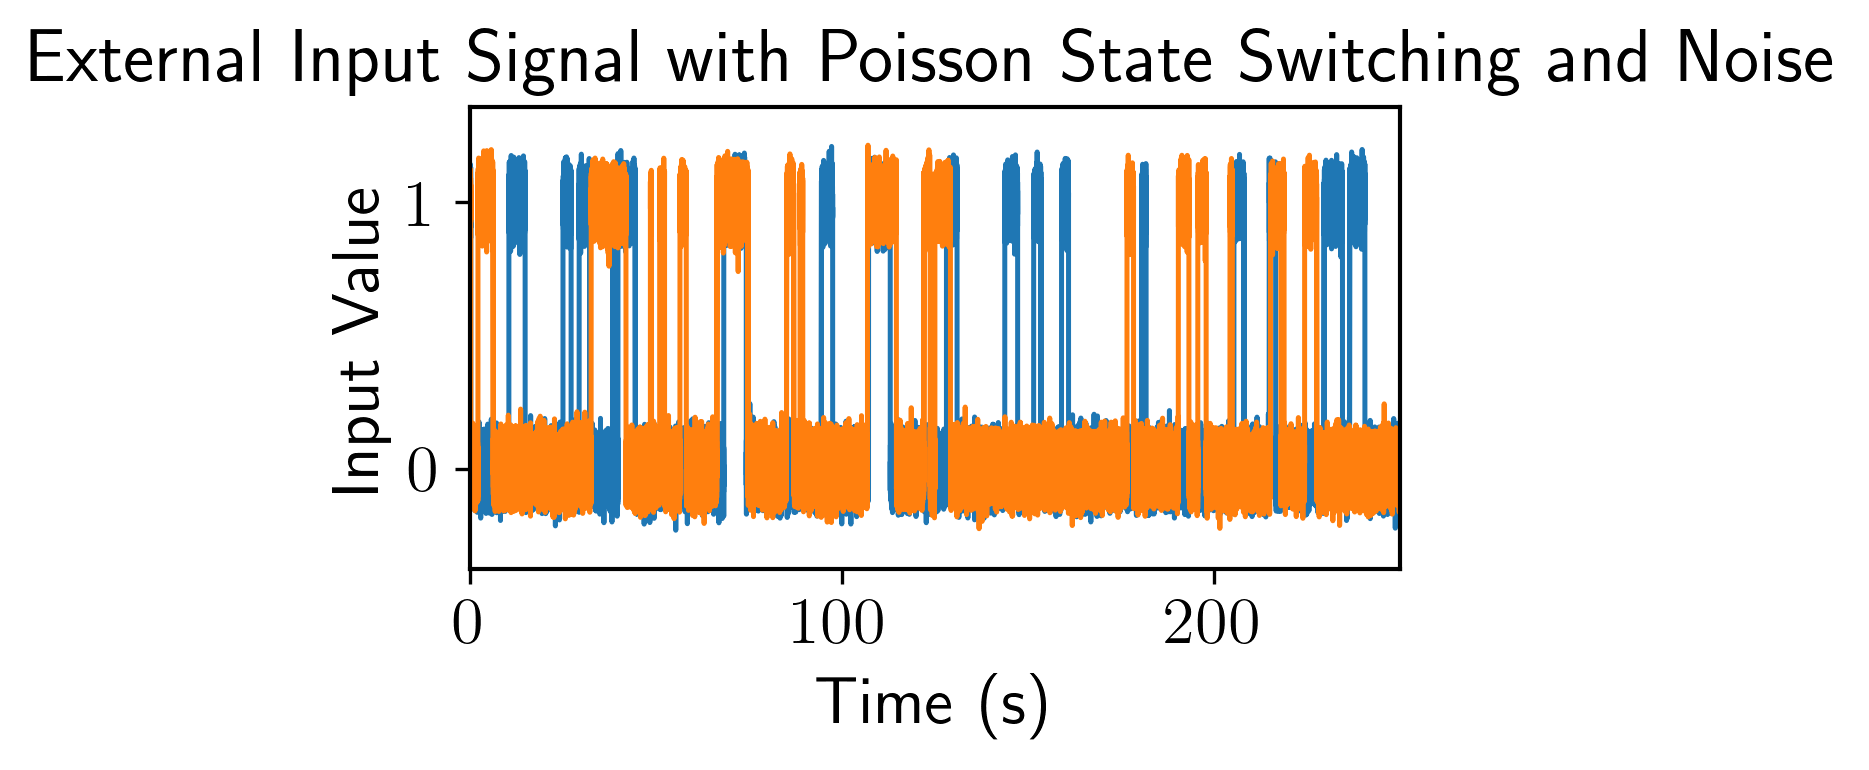

In [3]:
#Plotting the external input to each node
plot_input_Poisson = True
if plot_input_Poisson:
    plt.figure(figsize=(4, 2), dpi = 300)
    plt.plot(time_points, external_input, label='External Input with Noise')
    plt.title("External Input Signal with Poisson State Switching and Noise")
    plt.xlabel("Time (s)")
    plt.ylabel("Input Value")
    plt.show()

#### Neural dynamics $z$

In [4]:
def linear_DMC(t, z, A, sigma, C, u):
    '''
    The neural linear dynamics with adjacency matrix A and external input u

    Parameters
    ----------
    t : numpy float 
        Evaluation of the ODE at time t.
    z : numpy array - size N
        Neural state.
    A : numpy array
        Adjacency matrix.
    sigma : numpy float
        Scaling time lag.
    C : numpy array
        Coupling matrix for the external inputs.
        According to the original paper, this matrix is identity.
    u : function
        External input.

    Returns
    -------
    numpy array
        Neural state vector field at time t.
    '''    
    
    return sigma*(A @ z) + C @ u(t)


# Import input data from NetSim
# Adjacency matrix
A = np.array([[-1, 0], [0.4, -1]])
#Coupling matrix for the external inputs
C = np.identity(N)
#Initial conditions for the neural states
ic = np.zeros(N)
initial_condition = np.array(ic)

#The external input is given by evaluating the simulated process at each time t
def u_ext(t, dt = dt):
    return external_input[int(t/dt), :]

#The scaling time lag
sigma = 20
#Total amount of time to simulate the neural dynamics
neural_time = total_time
#Step size of the neural dynamics
sampling_dt = dt #0.05
t_eval = np.arange(0.0, neural_time, sampling_dt)

sol = solve_ivp(linear_DMC, [0, neural_time], initial_condition,
                method='RK45',
                args=(A, sigma, C, u_ext), t_eval = t_eval, 
                first_step = dt, 
                max_step = dt,
                rtol = 1e-4,
                atol = 1e-5)

X_t = sol.y.T

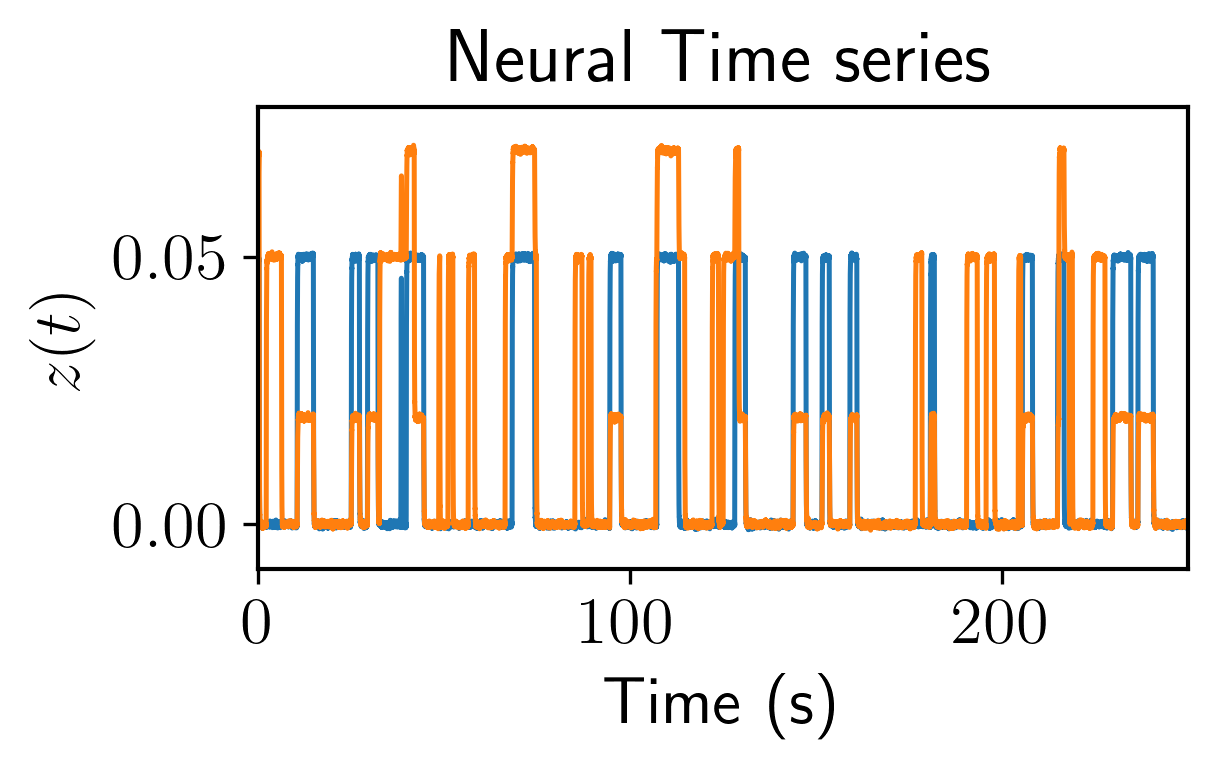

In [5]:
#Plotting the neural time series
plot_neural_timeseries = True
if plot_neural_timeseries:
    plt.figure(figsize=(4, 2), dpi = 300)
    plt.plot(t_eval, X_t, label='Neural Time series')
    plt.title("Neural Time series")
    plt.xlabel(r"Time (s)")
    plt.ylabel(r"$z(t)$")
    plt.show()    

## Hemodynamic model

The given underlying neural activity ---  which is modeled by our linear neural dynamics --- is convolved, or smoothed with a hemodynamic response. This nonlinear response is strongly based on two components: 

- the nonlinear Ballon model (by Buxton et al., 1998) --- a biomechanical model for the dynamic changes in deoxyhemoglobin content during brain activation,
- and a simple linear dynamical model of changes in regional cerebral blood flow (rCBF) caused by neural activity.

In order words, it models vascular dynamics on top of the neural activity. In particular, the model captures how evoked changes in blood flow were transformed into a blood oxygenation level-dependent (BOLD) signal. 

For each brain region $i$, the neural activity of that region is convoluted by the following dynamics:

$
{\Large
\begin{align*}
\dot{s}_i &= z_i - \kappa_i s_i - \gamma_i (f_i - 1)\\
\dot{f}_i &= s_i \\
\tau_i \dot{v}_i &= f_i - v_i^{1/\alpha} \\ 
\tau_i\dot{q}_i &= \frac{f_i}{\rho_i} E(f_i, \rho_i) - \frac{v_i^{1/\alpha}q_i}{v_i}, \\ 
\end{align*}
}
$

where $s_i$ is the vasodilatory signal, $v_i$ is the volume, $q_i$ is the deoxyhemoglobin content, and $f_i$ is the inflow from the venous compartment. The fraction of oxygen extracted from
the inflowing blood is given by 

$
\Large
E(f, \rho) = 1 - (1 - \rho)^{\frac{1}{f}}.
$ 

In [6]:
def E(f, rho):
    '''
    Oxigen extraction is a function of the flow and the resting oxigen 
    extraction fraction.
    

    Parameters
    ----------
    f : numpy float
        Inflow.
    rho : numpy float
        the resting oxigen extraction fraction.

    Returns
    -------
    numpy array
        
    '''    
    return 1.0 - np.power(1.0 - rho, 1.0/f)

def hemodyn_model(t, state, z, kappa, gamma, tau, alpha, rho):
    '''
    The hemodynamic state equations

    Parameters
    ----------
    t : numpy float
        Evaluation of the ODE at time t.
    state : numpy array - size N*4
        State variables of the hemodynamic state equations. 
        The organization of the states is given by
        
        s1, s2, ..., sN, f1, f2, ..., fN, v1, v2, ..., vN, q1, q2, ..., qN.
    z : function
        Neural input to each node to be filtered by the hemodynamic dynamics.
    kappa : numpy array
        Parameters.
    gamma : numpy array
        Parameters.
    tau : numpy array
        Parameters.
    alpha : numpy array
        Parameters.
    rho : numpy array
        Parameters.

    Returns
    -------
    TYPE
        DESCRIPTION.

    '''
    #Extract state variables from state following the organization described above.
    
    id_comp = 0
    s = state[id_comp*N:N+id_comp*N]
    id_comp = 1
    f = state[id_comp*N:N+id_comp*N] 
    id_comp = 2
    v = state[id_comp*N:N+id_comp*N]
    id_comp = 3
    q = state[id_comp*N:N+id_comp*N]
    
    v_alpha = np.power(v, 1/alpha)
    
    s_dot = z(t) - kappa*s - gamma*(f - 1)
    f_dot = s
    v_dot = (f - v_alpha)/tau
    q_dot = (f*E(f, rho)/rho - v_alpha*q/v)/tau
    
    return np.concatenate((s_dot, f_dot, v_dot, q_dot))
    
# Set of parameters for the hemodynamic dynamics model. 
# These parameters values are based on the DCM - Friston et al., 2003.
kappa = 0.65
gamma = 0.41
tau = 0.98
alpha = 0.32
rho = 0.34
kappa_vec = np.ones(N)*kappa
gamma_vec = np.ones(N)*gamma
tau_vec = np.ones(N)*tau
alpha_vec = np.ones(N)*alpha
rho_vec = np.ones(N)*rho

#Time parameters for the simulation of the hemodynamic dynamics.
blood_time = neural_time - dt
sampling_blood_dt = dt
t_blood_eval = np.arange(0.0, blood_time, sampling_blood_dt)

s0 = 0.0
s0_vec = s0 + rng.normal(0, scale = 1e-1, size = N)
ic_blood = np.concatenate((s0_vec, np.ones(N*3)))


def z_input(t, dt = sampling_blood_dt):
    return X_t[int(t/sampling_blood_dt), :]

#z = lambda t: X_t[int(t/BOLD_dt), :]

sol = solve_ivp(hemodyn_model, [0, blood_time], ic_blood,
                method='RK45',
                args=(z_input, kappa_vec, gamma_vec, tau_vec, alpha_vec, rho_vec), 
                t_eval = t_blood_eval, 
                first_step = dt, 
                max_step = dt,
                rtol = 1e-4,
                atol = 1e-5)

blood_flow_t = sol.y.T   
        

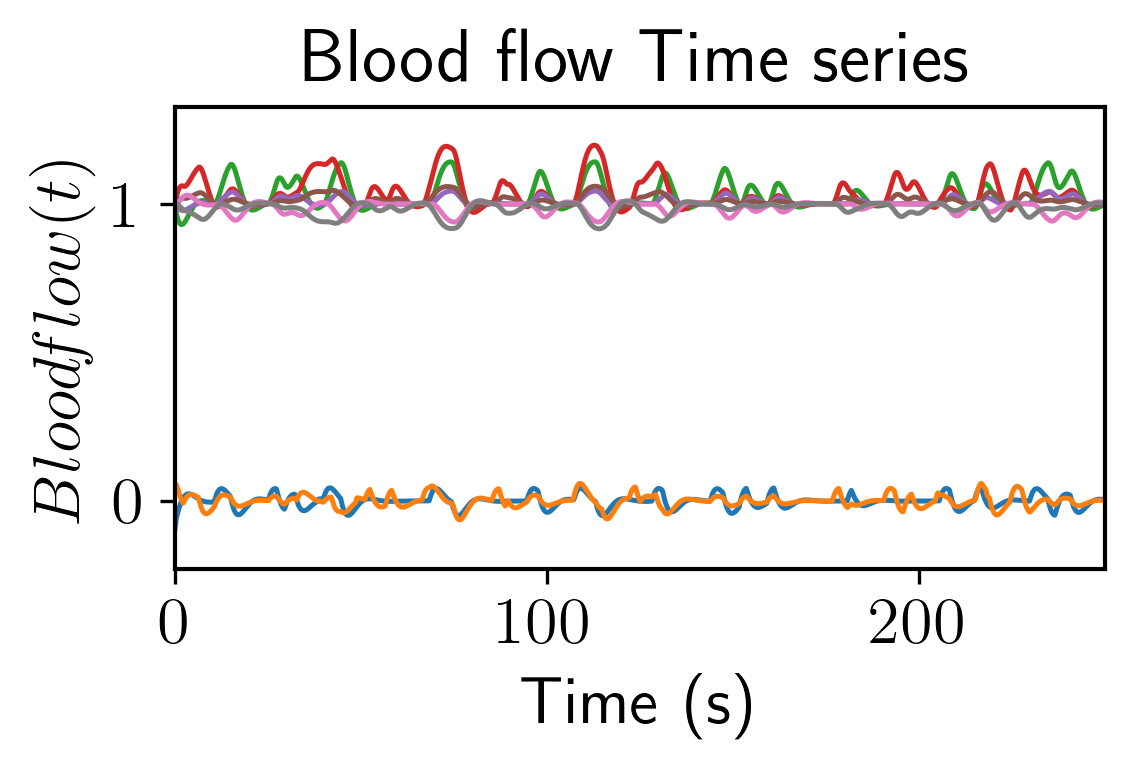

In [7]:
#Plotting the vasodilatory signal, blood volume, inflow and Deoxyhemoglobin content.
plot_blood_flow_timeseries = True
if plot_blood_flow_timeseries:
    plt.figure(figsize=(4, 2), dpi = 300)
    plt.plot(t_blood_eval, blood_flow_t)
    plt.title("Blood flow Time series")
    plt.xlabel(r"Time (s)")
    plt.ylabel(r"$Blood flow(t)$")
    plt.show()        

### BOLD signal

The BOLD signal y(t) is taken to be a static nonlinear function of normalized venous volume ($v$), normalized total deoxyhemoglobin voxel content ($q$), and resting net oxygen extraction fraction by the capillary bed ($\rho$)

$
\Large{
\begin{align*}
y(t) = V_0 \Big( k_1 (1 - q_i(t)) + k_2 (1 - \frac{q_i}{v_i}) + k_3 (1 - v_i)\Big)
\end{align*}
}
$

$k_1$, $k_2$ and $k_3$ are given. 


In [8]:
#=============================================================================#
def MR_signal(q, v, V0, k1, k2, k3):    
    '''
    The observation nonlinear function of volume and deoxyhemoglobin that
    comprises a volume-weighted sum or extra- and intra- vascular signals.

    Parameters
    ----------
    q : numpy array
        Deoxyhemoglobin content.
    v : numpy array
        Blood volume.
    V0 : numpy float 
        Resting blood volume fraction.
    k1 : numpy float
        Constant.
    k2 : numpy float
        Constant.
    k3 : numpy float
        Constant.
    
    Those V0, k1-k3 constants are determined based on the DCM - Friston et al., 2003.
        
    Returns
    -------
    numpy float
        Nonlinear function.

    '''
    kprime = k1*(1.0 - q) + k2*(1.0 - (q/v)) + k3*(1.0 - v)
    
    return V0*(kprime)

id_comp = 2
v = blood_flow_t[:, 0+id_comp*N:N+id_comp*N]
id_comp = 3
q = blood_flow_t[:, 0+id_comp*N:N+id_comp*N]

k1 = 7*rho_vec
k2 = 2
k3 = 2*rho_vec - 0.2
V0 = 0.02
BOLD_t_ = MR_signal(q, v, V0, k1, k2, k3)

thermal_white_noise = rng.normal(0, scale = 0.05*BOLD_t_.mean(axis=0), 
                                 size = BOLD_t_.shape)
BOLD_t_ =  BOLD_t_ + thermal_white_noise

sampling_BOLD_dt = 3
t_BOLD_eval = np.arange(0.0, blood_time, sampling_BOLD_dt)
BOLD_t = BOLD_t_[np.array(t_BOLD_eval/sampling_blood_dt, dtype = int), :]

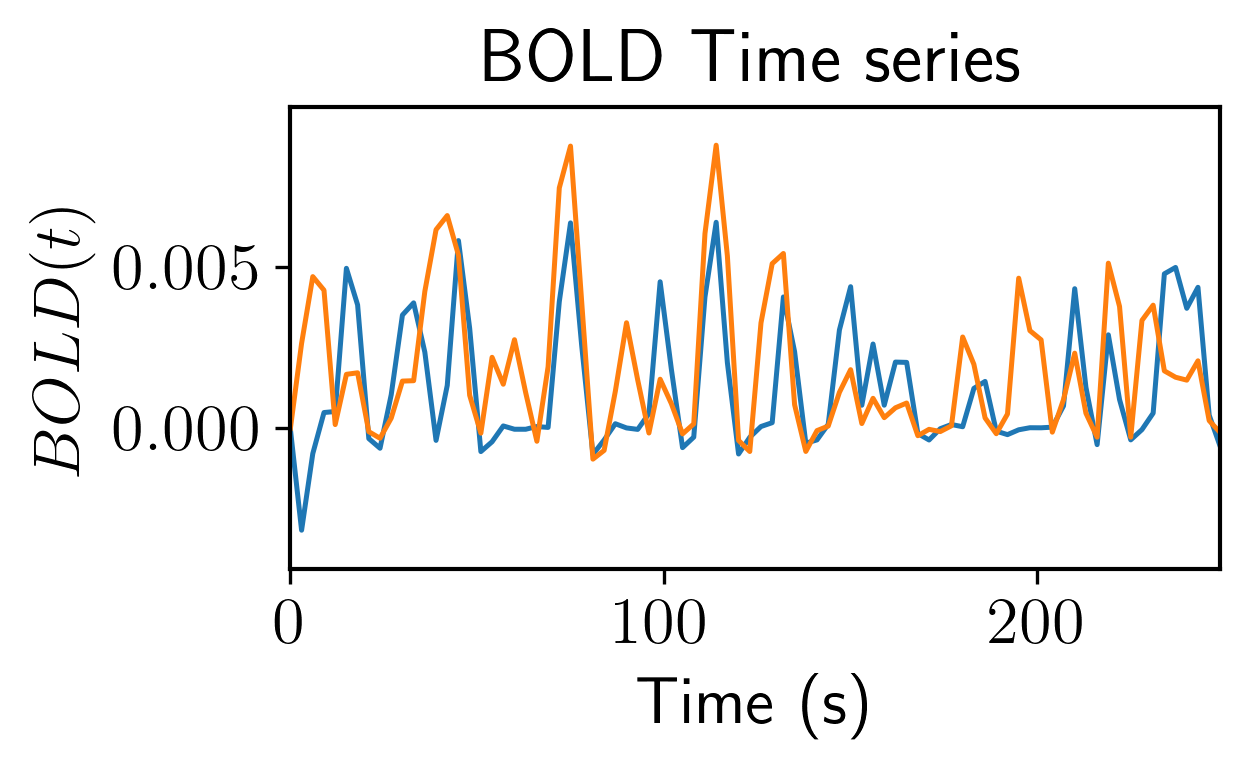

In [9]:
plot_BOLD_timeseries = True
if plot_BOLD_timeseries:
    plt.figure(figsize=(4, 2), dpi = 300)
    plt.plot(t_BOLD_eval, BOLD_t, label='BOLD Time series')
    plt.title("BOLD Time series")
    plt.xlabel(r"Time (s)")
    plt.ylabel(r"$BOLD(t)$")
    plt.show()     

#### Questions:

- *The amplitude of the neural timeseries were set so that the amount of nonlinearity matched what is seen in typical **3 T FMRI data**, and BOLD % signal change amplitudes of approximately 4% resulted (relative to mean intensity of simulated timecourses).* 

What does it mean 3 T FMRI data?

- 
